In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [16]:
# =========================
# 0) CONFIG (F4)
# =========================

FN = "F4"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---- Data paths (same structure as F1–F3) ----
INPUTS_PATH = "data/F4/initial_inputs.npy"
OUTPUTS_PATH = "data/F4/initial_outputs.npy"

# ---- Bounds (scaled 0–1) ----
BOUNDS = np.array([
    [0.0, 1.0],  # x1
    [0.0, 1.0],  # x2
    [0.0, 1.0],  # x3
    [0.0, 1.0],  # x4
], dtype=float)

# ---- BO parameters ----
N_CAND = 8192
KAPPA = 2.5              # UCB exploration strength
DIVERSITY_LAMBDA = 0.10  # penalize near-duplicate points
TOPK = 10                # show top candidates

In [17]:
# =========================
# 1) LOAD DATA
# =========================
X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH)

# ensure y is 1D
y = np.ravel(y)

print(f"{FN} SHAPE - Inputs:", X.shape, "Outputs:", y.shape)
print("Last values - input:", X[-1:], "output:", y[-1:])
print("y min/max:", float(y.min()), float(y.max()))


F4 SHAPE - Inputs: (32, 4) Outputs: (32,)
Last values - input: [[0.973744 0.941398 0.857228 0.989443]] output: [-46.39338782]
y min/max: -46.39338781605223 0.5802719111663213


In [18]:
# =========================
# 2) SURROGATE: ENSEMBLE TREES (mean + uncertainty)
# =========================
from sklearn.ensemble import ExtraTreesRegressor
import numpy as np

EPS = 1e-8  # numerical stability for sigma

def fit_ensemble(X, y, n_models=12, n_estimators=600, seed0=1000):
    models = []
    for i in range(n_models):
        m = ExtraTreesRegressor(
            n_estimators=n_estimators,
            random_state=seed0 + i,
            max_features="sqrt",   # <- encourages diversity (better uncertainty)
            min_samples_leaf=1,
            bootstrap=False,
            n_jobs=-1
        )
        m.fit(X, y)
        models.append(m)
    return models

def ensemble_predict(models, Xcand):
    preds = np.vstack([m.predict(Xcand) for m in models])  # (M, N)
    mu = preds.mean(axis=0)
    sig = preds.std(axis=0, ddof=1)
    sig = np.maximum(sig, EPS)  # avoid zeros
    return mu, sig

models = fit_ensemble(X, y)

mu_train, sig_train = ensemble_predict(models, X)
print("Sanity: train predicted mean range:", float(mu_train.min()), float(mu_train.max()))
print("Sanity: train predicted sigma range:", float(sig_train.min()), float(sig_train.max()))


Sanity: train predicted mean range: -46.39338781605249 0.5802719111663298
Sanity: train predicted sigma range: 1e-08 1e-08


In [19]:
# =========================
# 3) ACQUISITION: UCB + DIVERSITY PENALTY
# =========================
from scipy.stats.qmc import Sobol
import numpy as np

# Sobol candidate pool in [0,1]^4
d = X.shape[1]
sampler = Sobol(d=d, scramble=True, seed=RANDOM_SEED)

m = int(np.ceil(np.log2(N_CAND)))
Xcand = sampler.random_base2(m=m)[:N_CAND]

# clip to bounds
for j in range(d):
    Xcand[:, j] = np.clip(Xcand[:, j], BOUNDS[j, 0], BOUNDS[j, 1])

# surrogate predictions
mu, sig = ensemble_predict(models, Xcand)

# UCB (maximize)
ucb = mu + KAPPA * sig

# Diversity penalty (bounded + stable)
# Compute squared L2 distance to nearest observed point
d2 = ((Xcand[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)  # (N_CAND, N_obs)
min_d2 = d2.min(axis=1)

# lengthscale r: typical spacing in [0,1]^4 (simple heuristic)
r = 0.10
penalty = DIVERSITY_LAMBDA * np.exp(-min_d2 / (2 * r * r))

score = ucb - penalty

best_cand_idx = int(np.argmax(score))
x_next = Xcand[best_cand_idx]


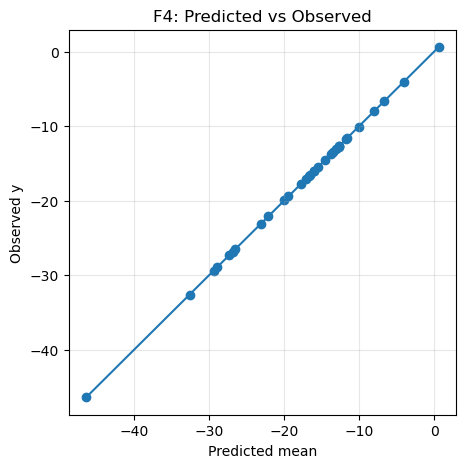

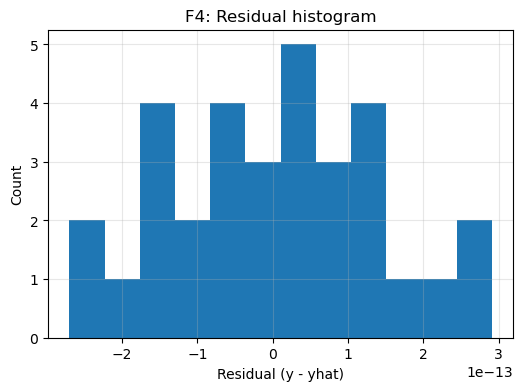

Min distance of x_next to existing data: 0.02163912465630964


,x1,x2,x3,x4,mu,sigma,ucb,min_dist_to_data,score
0,0.415091,0.447439,0.379873,0.420895,-1.235867,0.139526,-0.887052,0.021639,-0.984738
1,0.469464,0.409841,0.365454,0.389347,-2.748990,0.213653,-2.214857,0.069204,-2.293562
2,0.398050,0.434198,0.407300,0.316278,-3.016907,0.161879,-2.612210,0.103764,-2.670581
3,0.570146,0.453446,0.394642,0.437823,-4.284786,0.258657,-3.638144,0.159490,-3.666175
4,0.350888,0.440084,0.404003,0.281112,-4.384234,0.211582,-3.855280,0.151083,-3.887220
5,0.424395,0.399481,0.400456,0.170101,-4.420183,0.210895,-3.892946,0.147931,-3.926428
6,0.514049,0.431473,0.350440,0.468853,-4.728759,0.269708,-4.054489,0.119301,-4.103573
7,0.449829,0.337830,0.425977,0.362866,-5.065461,0.338341,-4.219609,0.117373,-4.269825
8,0.433344,0.319104,0.346777,0.436513,-5.172490,0.379849,-4.222869,0.120788,-4.271085
9,0.466965,0.458123,0.331877,0.347234,-4.853994,0.169358,-4.430599,0.109152,-4.485716


In [20]:
# =========================
# 4) DIAGNOSTICS
# =========================

# Predicted vs observed on training
plt.figure(figsize=(5,5))
plt.scatter(mu_train, y)
lo, hi = float(min(mu_train.min(), y.min())), float(max(mu_train.max(), y.max()))
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Predicted mean")
plt.ylabel("Observed y")
plt.title(f"{FN}: Predicted vs Observed")
plt.grid(True, alpha=0.3)
plt.show()

# Residuals
resid = y - mu_train
plt.figure(figsize=(6,4))
plt.hist(resid, bins=12)
plt.xlabel("Residual (y - yhat)")
plt.ylabel("Count")
plt.title(f"{FN}: Residual histogram")
plt.grid(True, alpha=0.3)
plt.show()

# Check whether proposal is "new" (not too close to existing points)
d2_next = ((X - x_next)**2).sum(axis=1)
min_dist_next = float(np.sqrt(d2_next.min()))
print("Min distance of x_next to existing data:", min_dist_next)

# Show top candidates table (backups)
top_idx = np.argsort(score)[-TOPK:][::-1]
proposals = pd.DataFrame(Xcand[top_idx], columns=[f"x{i+1}" for i in range(d)])
proposals["mu"] = mu[top_idx]
proposals["sigma"] = sig[top_idx]
proposals["ucb"] = ucb[top_idx]

# if you computed min_dist earlier, keep this:
proposals["min_dist_to_data"] = min_dist[top_idx]

# (if you used min_d2 instead, swap the above line for this)
# proposals["min_dist_to_data"] = np.sqrt(min_d2[top_idx])

proposals["score"] = score[top_idx]
proposals



In [21]:
# =========================
# 5) OUTPUT: ONE ROW TO SUBMIT
# =========================

x_submit = np.asarray(x_next).reshape(-1)

print("=== X VALUES TO SUBMIT (1 row only) ===")
print(x_submit)
print("Shape:", x_submit.shape)

print("\nRounded (6 dp):", np.round(x_submit, 6))

print("\n=== TOP 5 BACKUPS (rows) ===")
print(np.round(proposals[[f'x{i+1}' for i in range(d)]].head(5).to_numpy(), 6))


=== X VALUES TO SUBMIT (1 row only) ===
[0.41509075 0.44743895 0.37987313 0.42089527]
Shape: (4,)

Rounded (6 dp): [0.415091 0.447439 0.379873 0.420895]

=== TOP 5 BACKUPS (rows) ===
[[0.415091 0.447439 0.379873 0.420895]
 [0.469464 0.409841 0.365454 0.389347]
 [0.39805  0.434198 0.4073   0.316278]
 [0.570146 0.453446 0.394642 0.437823]
 [0.350888 0.440084 0.404003 0.281112]]


In [22]:
# =========================
# FINAL: CONFIRM SUBMISSION X
# =========================
print("Final X to submit:")
print(x_submit)
print("Shape:", x_submit.shape)



Final X to submit:
[0.41509075 0.44743895 0.37987313 0.42089527]
Shape: (4,)
